# B2 — ConvNeXt V2-T + MC Dropout (T=30)

B2 uses ConvNeXt V2-T, standard softmax cross-entropy, MC Dropout with T=30 and p=0.5 before the final classifier, and class-discriminative Grad-CAM. It retains the same patient-level 5-fold protocol, calibration metrics, rejection curves, efficiency measures, reproducibility controls and output schema as B1.

The current run is a 20-patient pilot. Set `PILOT_MAX_PATIENTS=None` for the full experiment. B2 supplies the same-backbone softmax/MC-Dropout reference needed for those comparisons.


In [ ]:
#@title 1. Install dependencies
!pip -q install scikit-learn scipy matplotlib pandas pillow tqdm thop timm

In [ ]:
#@title 2. Imports and global configuration
import os, json, math, time, copy, random, warnings, gc
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import wilcoxon

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.model_selection import StratifiedGroupKFold, GroupKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss, confusion_matrix
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm
from thop import profile

warnings.filterwarnings('ignore')

PILOT_MAX_PATIENTS = 50   # set to None for the full dataset
SEED = 42
NUM_CLASSES = 3
CLASS_NAMES = ['benign', 'indeterminate', 'malignant']
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10
LEARNING_RATE = 1e-4
MIN_LEARNING_RATE = 1e-6
WEIGHT_DECAY = 0.01
MC_T = 30
DROPOUT_P = 0.5
TIMM_MODEL_NAME = 'convnextv2_tiny.fcmae_ft_in1k'
ECE_BINS = 15

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
#@title 3. Reproducibility
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass
seed_everything(SEED)

In [ ]:
#@title 4. Mount Google Drive and create the agreed shared folder structure
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path('/content/drive/MyDrive/LIDC_Thesis')
LIDC_ROOT = PROJECT_ROOT / 'LIDC'
PROCESSED_ROOT = LIDC_ROOT / 'processed'
PATCH_ROOT = PROCESSED_ROOT / 'patches'
METADATA_ROOT = PROCESSED_ROOT / 'metadata'

B2_ROOT = PROJECT_ROOT / 'experiments' / 'B2_ConvNeXtV2T_MC_Dropout_T30'
NOTEBOOK_ROOT = B2_ROOT / 'notebooks'
CONFIG_ROOT = B2_ROOT / 'configs'
SPLIT_ROOT = B2_ROOT / 'splits'
CHECKPOINT_ROOT = B2_ROOT / 'checkpoints'
PREDICTION_ROOT = B2_ROOT / 'predictions'
METRICS_ROOT = B2_ROOT / 'metrics'
GRADCAM_ROOT = B2_ROOT / 'gradcam'
PLOT_ROOT = B2_ROOT / 'plots'
LOG_ROOT = B2_ROOT / 'logs'
REPORT_ROOT = B2_ROOT / 'reports'

for p in [NOTEBOOK_ROOT, CONFIG_ROOT, SPLIT_ROOT, CHECKPOINT_ROOT, PREDICTION_ROOT,
          METRICS_ROOT, GRADCAM_ROOT, PLOT_ROOT, LOG_ROOT, REPORT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

METADATA_CSV = METADATA_ROOT / 'lidc_patches_metadata.csv'
DETAILED_METADATA_CSV = METADATA_ROOT / 'lidc_patches_metadata_detailed.csv'
print('PATCH_ROOT:', PATCH_ROOT)
print('B2_ROOT:', B2_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PATCH_ROOT: /content/drive/MyDrive/LIDC_Thesis/LIDC/processed/patches
B2_ROOT: /content/drive/MyDrive/LIDC_Thesis/experiments/B2_ConvNeXtV2T_MC_Dropout_T30


## 5. Expected patch organization

Preferred structure from the preprocessing notebook:

```text
MyDrive/LIDC_Thesis/LIDC/processed/patches/
├── benign/<patient_id>/*.png
├── indeterminate/<patient_id>/*.png
└── malignant/<patient_id>/*.png
```

Preferred metadata:

```text
image_path,patient_id,label
...
```

Labels: `0=benign`, `1=indeterminate`, `2=malignant`.

If the CSV is absent, the next cell reconstructs it from the class/patient folders.

In [ ]:
#@title 6. Build metadata from patient-wise patch folders (folder structure = source of truth)
LABEL_MAP = {'benign':0, 'indeterminate':1, 'malignant':2}
INV_LABEL_MAP = {v:k for k,v in LABEL_MAP.items()}

def rebuild_metadata_from_patches(root):
    """
    Expected structure:
      patches/
        benign/<patient_id>/*.png
        indeterminate/<patient_id>/*.png
        malignant/<patient_id>/*.png

    Returns one row per individual image patch.
    No NPZ archive is used.
    """
    rows = []
    exts = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}

    for class_name, label in LABEL_MAP.items():
        class_dir = Path(root) / class_name
        if not class_dir.exists():
            print(f"WARNING: class folder not found: {class_dir}")
            continue

        for fp in class_dir.rglob('*'):
            if not fp.is_file() or fp.suffix.lower() not in exts:
                continue

            rel = fp.relative_to(class_dir)

            # Preferred layout: <class>/<patient_id>/<patch_file>
            if len(rel.parts) < 2:
                print(f"Skipping patch not inside a patient folder: {fp}")
                continue

            patient_id = str(rel.parts[0])

            rows.append({
                'image_path': str(fp),
                'patient_id': patient_id,
                'label': int(label),
                'class_name': class_name,
                'patch_filename': fp.name,
            })

    return pd.DataFrame(rows)


# Always reconstruct the core training metadata from the actual folders.
# This avoids stale/legacy CSV schemas and guarantees patient_id matches folder grouping.
df = rebuild_metadata_from_patches(PATCH_ROOT)

if len(df) == 0:
    raise RuntimeError(
        f'No individual patch images found under {PATCH_ROOT}. Expected:\n'
        '  patches/benign/<patient_id>/*.png\n'
        '  patches/indeterminate/<patient_id>/*.png\n'
        '  patches/malignant/<patient_id>/*.png'
    )

# Optional: merge extra columns from an existing detailed metadata CSV.
# Core columns from folders are NEVER overwritten.
candidate_metadata = [
    DETAILED_METADATA_CSV,
    METADATA_CSV,
    METADATA_ROOT / 'nodule_metadata_filtered.csv',
]

extra_df = None
for meta_path in candidate_metadata:
    if meta_path.exists():
        try:
            tmp = pd.read_csv(meta_path)
            print(f'Found optional metadata: {meta_path}')
            print('Optional metadata columns:', list(tmp.columns))
            extra_df = tmp
            break
        except Exception as e:
            print(f'Could not read {meta_path}: {e}')

# If metadata contains a filename/path key, merge useful extra columns.
if extra_df is not None:
    merge_done = False

    # Normalize common legacy names without requiring patient_id.
    rename_map = {}
    if 'label_id' in extra_df.columns and 'label' not in extra_df.columns:
        rename_map['label_id'] = 'label'
    if 'label_name' in extra_df.columns and 'class_name' not in extra_df.columns:
        rename_map['label_name'] = 'class_name'
    if rename_map:
        extra_df = extra_df.rename(columns=rename_map)

    # Create basename helper from any known path field.
    path_col = next((c for c in ['image_path', 'patch_path', 'file_path', 'filepath']
                     if c in extra_df.columns), None)

    if path_col is not None:
        extra_df = extra_df.copy()
        extra_df['_patch_filename'] = extra_df[path_col].astype(str).map(lambda x: Path(x).name)

        protected = {'image_path', 'patient_id', 'label', 'class_name', 'patch_filename'}
        extra_cols = [c for c in extra_df.columns
                      if c not in protected and c != '_patch_filename']

        if extra_cols:
            dedup = extra_df[['_patch_filename'] + extra_cols].drop_duplicates('_patch_filename')
            df = df.merge(
                dedup,
                left_on='patch_filename',
                right_on='_patch_filename',
                how='left'
            ).drop(columns=['_patch_filename'])
            merge_done = True
            print(f'Merged optional metadata columns: {extra_cols}')

    if not merge_done:
        print('Optional metadata was not merged because no reliable patch filename/path key was found.')
        print('Training will continue using folder-derived image_path, patient_id, and label.')

# Normalize types.
df['patient_id'] = df['patient_id'].astype(str)
df['label'] = df['label'].astype(int)
df['image_path'] = df['image_path'].astype(str)

# Defensive validation.
missing_files = ~df['image_path'].map(lambda p: Path(p).exists())
if missing_files.any():
    print(f'WARNING: removing {int(missing_files.sum())} rows whose image files do not exist.')
    df = df.loc[~missing_files].copy()

df = df.drop_duplicates('image_path').reset_index(drop=True)

if PILOT_MAX_PATIENTS is not None:
    chosen = sorted(df['patient_id'].unique())[:PILOT_MAX_PATIENTS]
    df = df[df['patient_id'].isin(chosen)].reset_index(drop=True)

if len(df) == 0:
    raise RuntimeError('No valid patch images remain after filtering.')

print('\nEffective dataset')
print('Patches:', len(df))
print('Patients:', df['patient_id'].nunique())
print('Columns:', list(df.columns))
print('\nClass distribution:')
print(df['class_name'].value_counts())

# Save an effective manifest for reproducibility.
# This is only a CSV index; patches remain as individual files.
effective_path = METADATA_ROOT / 'B2_effective_metadata.csv'
df.to_csv(effective_path, index=False)
print('\nSaved:', effective_path)

Found optional metadata: /content/drive/MyDrive/LIDC_Thesis/LIDC/processed/metadata/lidc_patches_metadata_detailed.csv
Optional metadata columns: ['image_path', 'patient_id', 'label', 'class_name', 'xml_path', 'series_uid', 'match_type', 'cluster_index', 'reader_count', 'reader_ids', 'median_malignancy', 'malignancy_values', 'diameter_mm_est', 'slice_index', 'slice_z_mm', 'centroid_x_px', 'centroid_y_px', 'cross_section_area_px2']
Merged optional metadata columns: ['xml_path', 'series_uid', 'match_type', 'cluster_index', 'reader_count', 'reader_ids', 'median_malignancy', 'malignancy_values', 'diameter_mm_est', 'slice_index', 'slice_z_mm', 'centroid_x_px', 'centroid_y_px', 'cross_section_area_px2']

Effective dataset
Patches: 94
Patients: 38
Columns: ['image_path', 'patient_id', 'label', 'class_name', 'patch_filename', 'xml_path', 'series_uid', 'match_type', 'cluster_index', 'reader_count', 'reader_ids', 'median_malignancy', 'malignancy_values', 'diameter_mm_est', 'slice_index', 'slice_

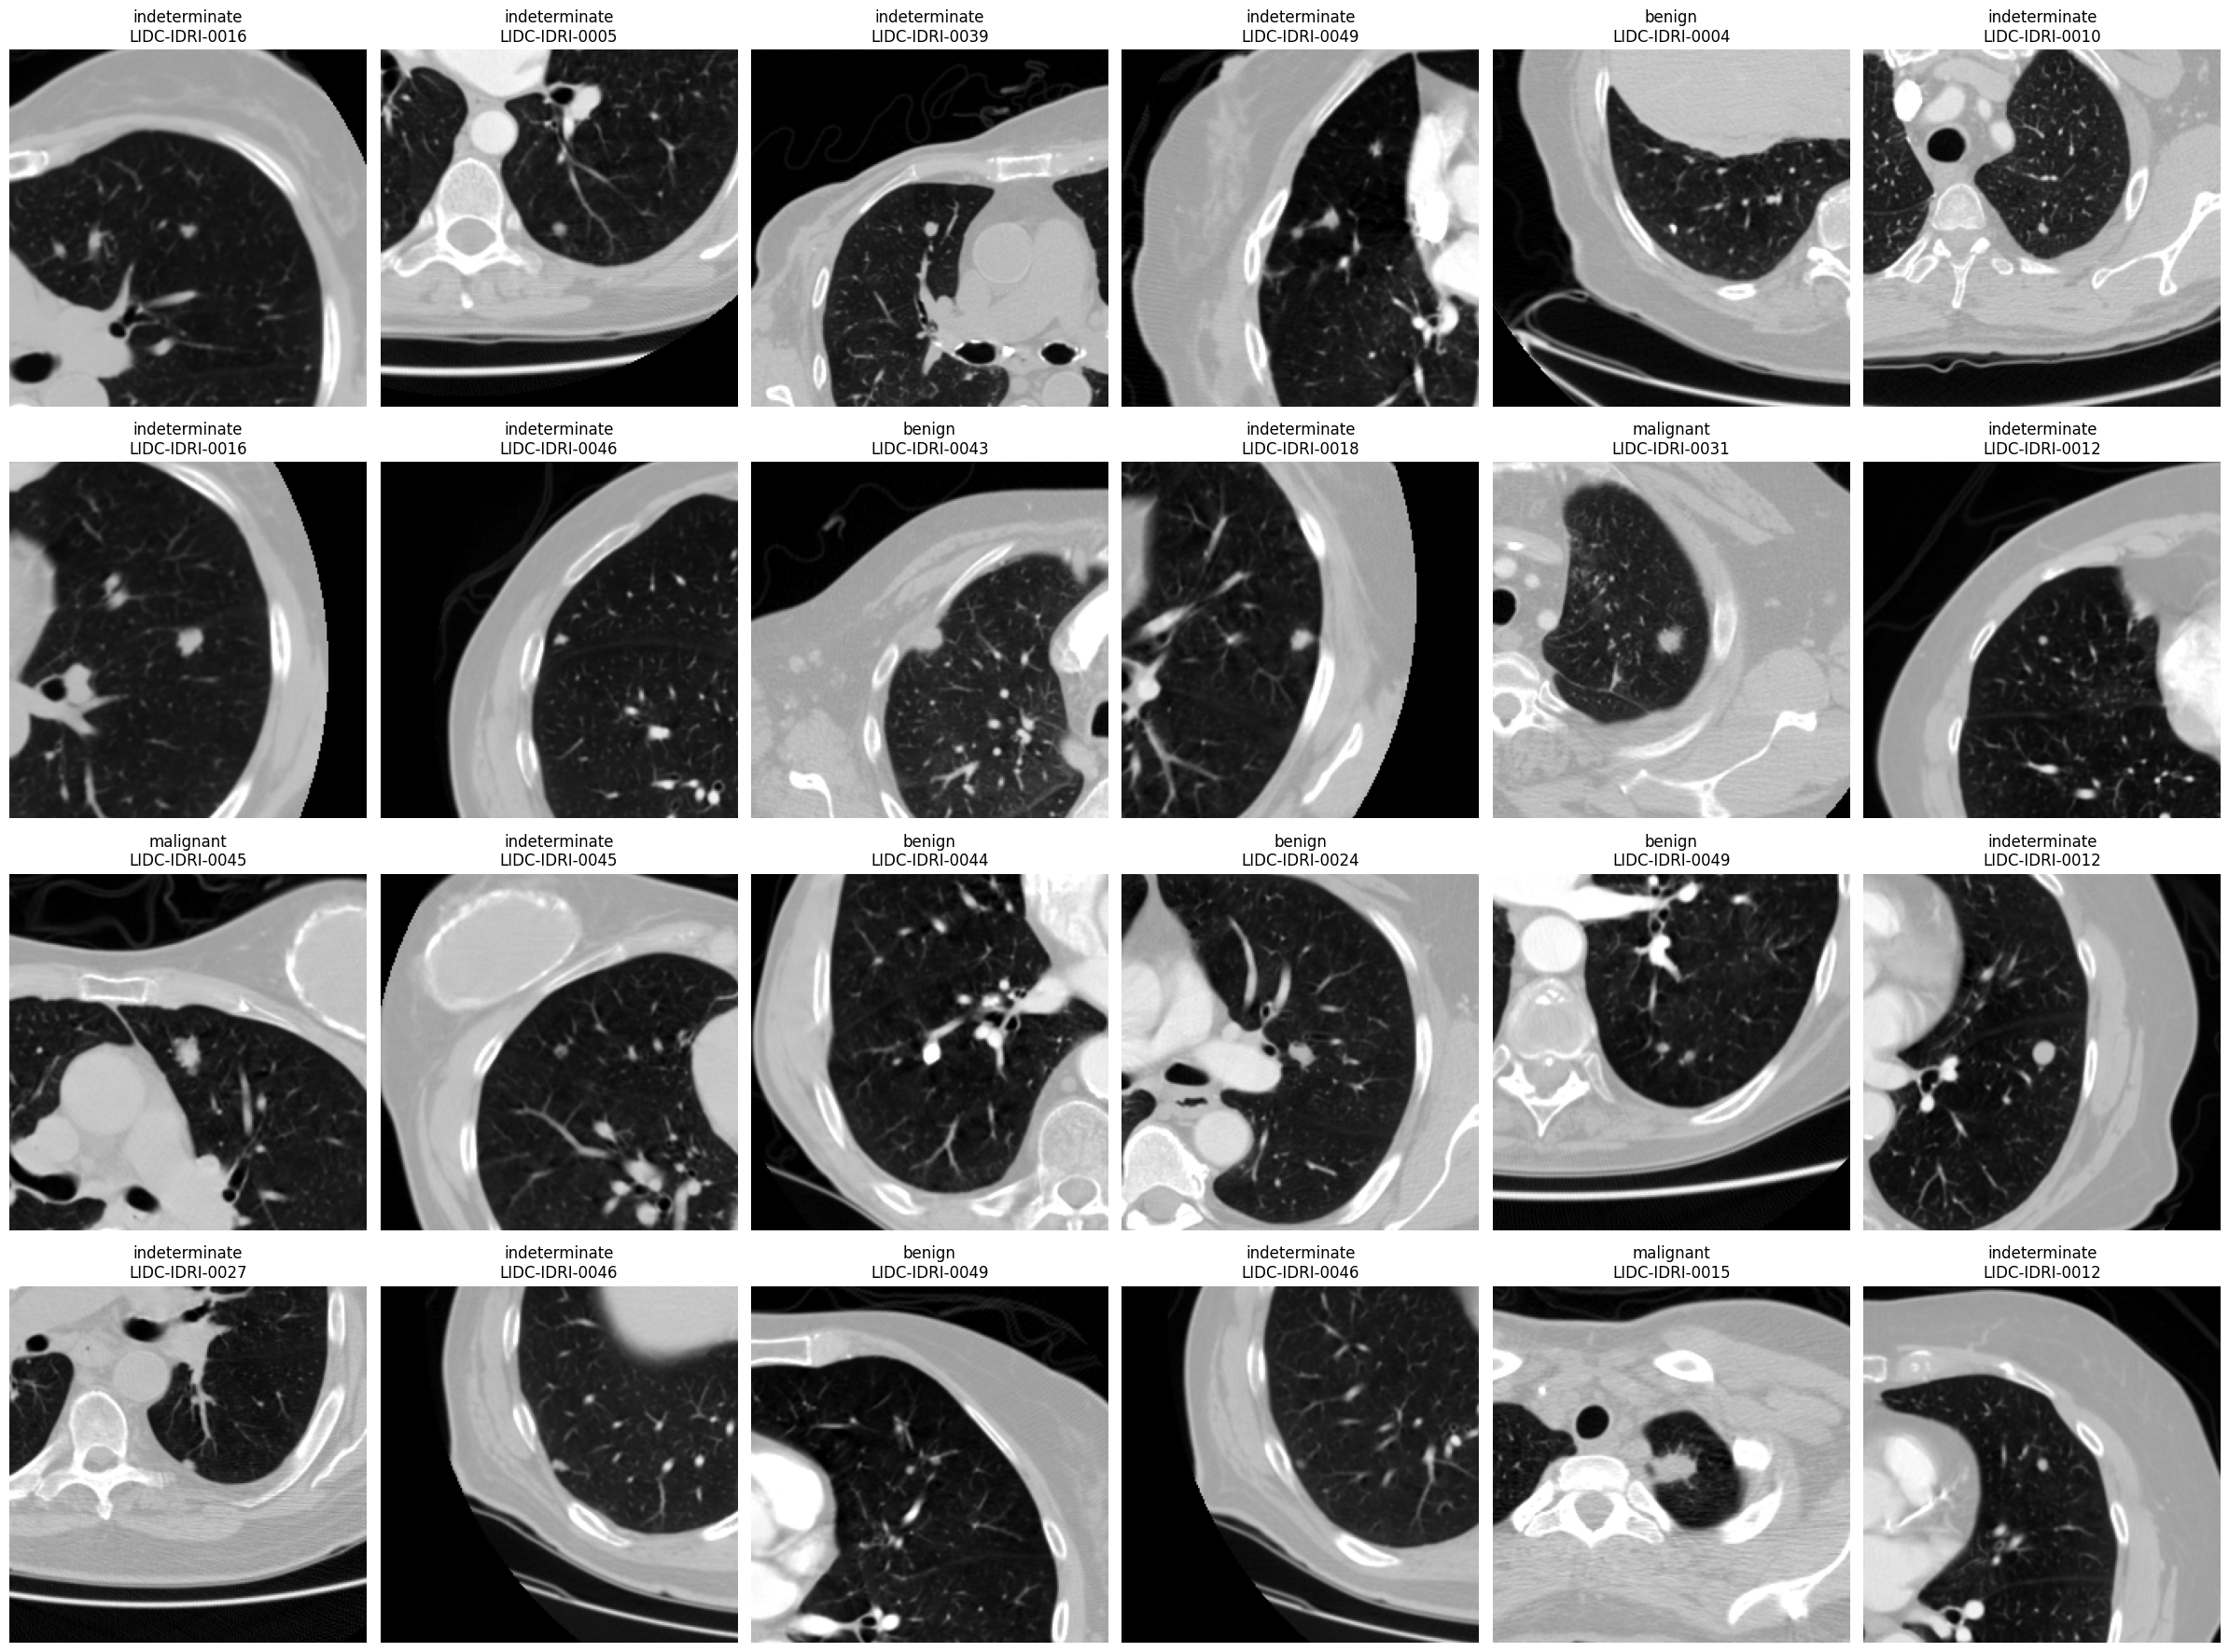

In [ ]:
#@title 7. Optional: inspect sample images
def show_samples(df, n=24):
    sample = df.sample(min(n, len(df)), random_state=SEED)
    fig, axes = plt.subplots(4, 6, figsize=(24, 18))
    axes = np.asarray(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(row["image_path"]).convert("L")
        ax.imshow(img, cmap="gray")
        ax.set_title(f'{CLASS_NAMES[int(row["label"])]}\n{row["patient_id"]}')
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(df)


In [ ]:
#@title 8. Dataset and transforms
# Proposal specifies 224x224 grayscale replicated to 3 channels.
# No extra augmentation is enabled here because it is not specified in the plan.
base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class LIDCPatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df=dataframe.reset_index(drop=True).copy()
        self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        with Image.open(row['image_path']) as img:
            img=img.convert('L')
            x=self.transform(img) if self.transform else transforms.ToTensor()(img)
        item={'image':x,'label':torch.tensor(int(row['label']),dtype=torch.long),
              'patient_id':str(row['patient_id']),'image_path':str(row['image_path'])}
        if 'mask_path' in self.df.columns:
            item['mask_path']=str(row.get('mask_path',''))
        return item

In [ ]:
#@title 9. Patient-level 5-fold split + patient-level validation split

def make_outer_splits(df,n_splits=5):
    X=np.zeros((len(df),1)); y=df['label'].values; groups=df['patient_id'].values
    try:
        sp=StratifiedGroupKFold(n_splits=n_splits,shuffle=True,random_state=SEED)
        splits=list(sp.split(X,y,groups)); method='StratifiedGroupKFold'
    except Exception as e:
        print('StratifiedGroupKFold unavailable for this pilot:',repr(e))
        sp=GroupKFold(n_splits=n_splits)
        splits=list(sp.split(X,y,groups)); method='GroupKFold fallback'
    return splits,method

def dominant_patient_labels(frame):
    return frame.groupby('patient_id')['label'].agg(lambda s:int(s.value_counts().index[0]))

def split_train_val_patients(trainval_df, fraction=0.10, seed=42):
    ptab=dominant_patient_labels(trainval_df)
    patients=ptab.index.to_numpy(); labels=ptab.values
    n=len(patients); n_val=max(1,min(n-1,int(round(n*fraction))))
    counts=Counter(labels)
    can_stratify=(len(counts)>=2 and min(counts.values())>=2 and n_val>=len(counts))
    if can_stratify:
        sss=StratifiedShuffleSplit(n_splits=1,test_size=n_val,random_state=seed)
        ti,vi=next(sss.split(patients,labels)); method='patient-stratified'
        trp=set(patients[ti]); vap=set(patients[vi])
    else:
        rng=np.random.RandomState(seed); shuffled=patients.copy(); rng.shuffle(shuffled)
        vap=set(shuffled[:n_val]); trp=set(shuffled[n_val:]); method='patient-random fallback'
    return (trainval_df[trainval_df.patient_id.isin(trp)].copy(),
            trainval_df[trainval_df.patient_id.isin(vap)].copy(),method)

outer_splits,outer_method=make_outer_splits(df,5)
print('Outer split:',outer_method)
folds=[]; manifest=[]
for fold,(trainval_idx,test_idx) in enumerate(outer_splits):
    print(f'\n Fold {fold+1}/{len(outer_splits)}')
    trainval=df.iloc[trainval_idx].copy(); test=df.iloc[test_idx].copy()
    train,val,val_method=split_train_val_patients(trainval,0.10,SEED+fold)
    assert set(train.patient_id).isdisjoint(set(val.patient_id))
    assert set(train.patient_id).isdisjoint(set(test.patient_id))
    assert set(val.patient_id).isdisjoint(set(test.patient_id))

    info={'fold':fold,'train':train.reset_index(drop=True),'val':val.reset_index(drop=True),'test':test.reset_index(drop=True)}
    folds.append(info)
    print(info)
    for name,frame in [('train',train),('val',val),('test',test)]:
        frame.to_csv(SPLIT_ROOT/f'fold_{fold}_{name}.csv',index=False)
        manifest.append({'fold':fold,'split':name,'patches':len(frame),'patients':frame.patient_id.nunique(),
                         'benign':int((frame.label==0).sum()),'indeterminate':int((frame.label==1).sum()),
                         'malignant':int((frame.label==2).sum()),'val_method':val_method if name!='test' else ''})
manifest_df=pd.DataFrame(manifest); manifest_df.to_csv(SPLIT_ROOT/'split_manifest.csv',index=False)
display(manifest_df)

Outer split: StratifiedGroupKFold

 Fold 1/5
{'fold': 0, 'train':                                            image_path      patient_id  label  \
0   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0004      0   
1   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0011      0   
2   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0021      0   
3   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0034      0   
4   /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0039      0   
..                                                ...             ...    ...   
61  /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0045      2   
62  /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0045      2   
63  /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0047      2   
64  /content/drive/MyDrive/LIDC_Thesis/LIDC/proces...  LIDC-IDRI-0048      2   
65  /content/drive/MyDrive/LIDC_Thesis/LIDC/proces... 

,fold,split,patches,patients,benign,indeterminate,malignant,val_method
0,0,train,66,29,10,39,17,patient-stratified
1,0,val,9,3,4,4,1,patient-stratified
2,0,test,19,6,5,11,3,
3,1,train,65,26,13,37,15,patient-stratified
4,1,val,7,3,2,4,1,patient-stratified
5,1,test,22,9,4,13,5,
6,2,train,56,26,12,29,15,patient-stratified
7,2,val,15,3,0,13,2,patient-stratified
8,2,test,23,9,7,12,4,
9,3,train,70,28,16,39,15,patient-stratified


In [ ]:
#@title 10. DataLoader construction
def make_loaders(train_df,val_df,test_df):
    kwargs=dict(batch_size=BATCH_SIZE,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
    return (DataLoader(LIDCPatchDataset(train_df,base_transform),shuffle=True,**kwargs),
            DataLoader(LIDCPatchDataset(val_df,base_transform),shuffle=False,**kwargs),
            DataLoader(LIDCPatchDataset(test_df,base_transform),shuffle=False,**kwargs))

In [ ]:
#@title 11. B2 ConvNeXt V2-T with dropout before the final classifier
class ConvNeXtV2TMCDropout(nn.Module):
    def __init__(self, num_classes=3, dropout_p=0.5, pretrained=True, model_name=TIMM_MODEL_NAME):
        super().__init__()
        # timm removes the original ImageNet classifier when num_classes=0.
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        in_features = int(self.backbone.num_features)
        self.dropout = nn.Dropout(p=dropout_p)
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        spatial = self.backbone.forward_features(x)
        pooled = self.backbone.forward_head(spatial, pre_logits=True)
        return self.classifier(self.dropout(pooled))

    def enable_dropout(self):
        # Keep normalization layers in eval mode while re-enabling dropout for MC inference.
        for module in self.modules():
            if isinstance(module, nn.Dropout):
                module.train()

model = ConvNeXtV2TMCDropout(
    num_classes=NUM_CLASSES,
    dropout_p=DROPOUT_P,
    pretrained=True
).to(DEVICE)

print('Backbone:', TIMM_MODEL_NAME)
print('Feature dimension:', model.backbone.num_features)
print('Final classifier:', model.classifier)


Backbone: convnextv2_tiny.fcmae_ft_in1k
Feature dimension: 768
Final classifier: Linear(in_features=768, out_features=3, bias=True)


In [ ]:
#@title 12. Required evaluation metrics
EPS=1e-12

def multiclass_brier_score(y_true,probs):
    oh=np.eye(NUM_CLASSES)[np.asarray(y_true,dtype=int)]
    return float(np.mean(np.sum((np.asarray(probs)-oh)**2,axis=1)))

def expected_calibration_error(y_true,probs,n_bins=15):
    y_true=np.asarray(y_true); probs=np.asarray(probs)
    conf=probs.max(1); pred=probs.argmax(1); correct=(pred==y_true).astype(float)
    edges=np.linspace(0,1,n_bins+1); ece=0.0
    for i,(lo,hi) in enumerate(zip(edges[:-1],edges[1:])):
        m=(conf>=lo)&(conf<=hi) if i==0 else (conf>lo)&(conf<=hi)
        if m.any(): ece+=m.mean()*abs(correct[m].mean()-conf[m].mean())
    return float(ece)

def safe_macro_auroc(y_true,probs):
    y=np.asarray(y_true,dtype=int); p=np.asarray(probs)
    yb=label_binarize(y,classes=[0,1,2]); vals=[]
    for k in range(NUM_CLASSES):
        if len(np.unique(yb[:,k]))<2: vals.append(np.nan)
        else: vals.append(roc_auc_score(yb[:,k],p[:,k]))
    return float(np.nanmean(vals)) if np.isfinite(vals).any() else np.nan

def compute_classification_metrics(y_true,probs):
    y=np.asarray(y_true,dtype=int); p=np.asarray(probs,dtype=float); pred=p.argmax(1)
    return {'accuracy':float(accuracy_score(y,pred)),
            'macro_f1':float(f1_score(y,pred,average='macro',zero_division=0)),
            'auroc_ovr_macro':safe_macro_auroc(y,p),
            'brier_score':multiclass_brier_score(y,p),
            'ece_15':expected_calibration_error(y,p,ECE_BINS),
            'nll':float(-np.mean(np.log(np.clip(p[np.arange(len(y)),y],EPS,1.0))))}

In [ ]:
#@title 13. Training and validation utilities
def standard_forward(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)

            total_loss += loss.item() * images.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    probabilities = np.concatenate(all_probs, axis=0)
    labels = np.asarray(all_labels)
    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_classification_metrics(labels, probabilities)
    metrics["loss"] = float(avg_loss)
    return metrics, labels, probabilities

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0

    for batch in loader:
        images = batch["image"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


In [ ]:
#@title 14. Train one fold with AdamW, cosine annealing, and Brier-based early stopping
def train_fold(train_loader, val_loader, fold_number, run_dir):
    model = ConvNeXtV2TMCDropout(
        num_classes=NUM_CLASSES,
        dropout_p=DROPOUT_P,
        pretrained=True
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        betas=(0.9, 0.999),
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=MAX_EPOCHS,
        eta_min=MIN_LEARNING_RATE
    )

    history = []
    best_state = None
    best_val_brier = float("inf")
    epochs_without_improvement = 0

    run_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_metrics, _, _ = standard_forward(model, val_loader, criterion)
        scheduler.step()

        record = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }
        history.append(record)

        print(
            f"Fold {fold_number} | Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_brier={val_metrics['brier_score']:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["brier_score"] < best_val_brier:
            best_val_brier = val_metrics["brier_score"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0

            torch.save(
                {
                    "fold": fold_number,
                    "epoch": epoch,
                    "model_state_dict": best_state,
                    "best_val_brier": best_val_brier,
                    "config": {
                        "backbone": "ConvNeXt V2-T",
                        "dropout_p": DROPOUT_P,
                        "mc_t": MC_T,
                        "seed": SEED
                    }
                },
                CHECKPOINT_ROOT / f"fold_{fold_number}_best.pt"
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)
    pd.DataFrame(history).to_csv(LOG_ROOT / f"fold_{fold_number}_history.csv", index=False)
    return model, pd.DataFrame(history)


In [ ]:
#@title 15. MC Dropout inference (T=30)
def enable_mc_dropout(model):
    model.eval()
    for m in model.modules():
        if isinstance(m,nn.Dropout): m.train()

@torch.no_grad()
def mc_dropout_predict(model,loader,T=30):
    enable_mc_dropout(model)
    passes=[]; labels=None; metadata=None
    for t in tqdm(range(T),desc=f'MC Dropout T={T}',leave=False):
        pp=[]; yy=[]; mm=[]
        for batch in loader:
            x=batch['image'].to(DEVICE,non_blocking=True)
            probs=torch.softmax(model(x),1).cpu().numpy(); pp.append(probs)
            if t==0:
                yy.extend(batch['label'].numpy().tolist())
                mm.extend([{'patient_id':p,'image_path':q} for p,q in zip(batch['patient_id'],batch['image_path'])])
        passes.append(np.concatenate(pp,0))
        if t==0: labels=np.asarray(yy); metadata=mm
    mc=np.stack(passes,0); mean=mc.mean(0)
    pred_ent=-np.sum(np.clip(mean,EPS,1)*np.log(np.clip(mean,EPS,1)),axis=1)
    exp_ent=-np.mean(np.sum(np.clip(mc,EPS,1)*np.log(np.clip(mc,EPS,1)),axis=2),axis=0)
    mi=pred_ent-exp_ent
    prob_var=mc.var(0).mean(1)
    plabel=mc.argmax(2); vr=[]
    for i in range(plabel.shape[1]):
        c=np.bincount(plabel[:,i],minlength=NUM_CLASSES); vr.append(1-c.max()/T)
    return {'mc_probs':mc,'mean_probabilities':mean,'labels':labels,'metadata':metadata,
            'predictive_entropy':pred_ent,'mutual_information':mi,
            'mean_probability_variance':prob_var,'variation_ratio':np.asarray(vr)}

In [ ]:
#@title 16. Save MC predictions and core metrics
def save_mc_results(mc_results,fold_number):
    p=mc_results['mean_probabilities']; y=mc_results['labels']
    metrics=compute_classification_metrics(y,p)
    metrics.update({'mean_predictive_entropy':float(mc_results['predictive_entropy'].mean()),
                    'mean_mutual_information':float(mc_results['mutual_information'].mean()),
                    'mean_probability_variance':float(mc_results['mean_probability_variance'].mean()),
                    'mean_variation_ratio':float(mc_results['variation_ratio'].mean())})
    rows=[]
    for i,m in enumerate(mc_results['metadata']):
        rows.append({'fold':fold_number,'patient_id':m['patient_id'],'image_path':m['image_path'],
                     'true_label':int(y[i]),'predicted_label':int(p[i].argmax()),
                     'p_benign':float(p[i,0]),'p_indeterminate':float(p[i,1]),'p_malignant':float(p[i,2]),
                     'predictive_entropy':float(mc_results['predictive_entropy'][i]),
                     'mutual_information':float(mc_results['mutual_information'][i]),
                     'mean_probability_variance':float(mc_results['mean_probability_variance'][i]),
                     'variation_ratio':float(mc_results['variation_ratio'][i])})
    pred_df=pd.DataFrame(rows)
    pred_df.to_csv(PREDICTION_ROOT/f'fold_{fold_number}_test_predictions.csv',index=False)
    np.savez_compressed(PREDICTION_ROOT/f'fold_{fold_number}_mc_probabilities_T30.npz',
                        mc_probs=mc_results['mc_probs'],mean_probs=p,y_true=y)
    return metrics,pred_df

In [ ]:
#@title 17. Predictive-entropy rejection curve + random rejection lower bound
def rejection_curve(labels,probs,uncertainty):
    y=np.asarray(labels); pred=np.asarray(probs).argmax(1); order=np.argsort(uncertainty)
    rows=[]; n=len(y)
    for kept in range(1,n+1):
        idx=order[:kept]
        rows.append({'coverage':kept/n,'accuracy':float(accuracy_score(y[idx],pred[idx]))})
    return pd.DataFrame(rows)

def random_rejection_curve(labels,probs,repeats=50,seed=42):
    y=np.asarray(labels); pred=np.asarray(probs).argmax(1); n=len(y); rng=np.random.RandomState(seed)
    arr=[]
    for _ in range(repeats):
        o=rng.permutation(n); arr.append([accuracy_score(y[o[:k]],pred[o[:k]]) for k in range(1,n+1)])
    arr=np.asarray(arr)
    return pd.DataFrame({'coverage':np.arange(1,n+1)/n,'accuracy':arr.mean(0),'accuracy_sd':arr.std(0)})

def save_rejection_curves(mc_results,fold):
    a=rejection_curve(mc_results['labels'],mc_results['mean_probabilities'],mc_results['predictive_entropy'])
    r=random_rejection_curve(mc_results['labels'],mc_results['mean_probabilities'],50,SEED+fold)
    a.to_csv(METRICS_ROOT/f'fold_{fold}_rejection_entropy.csv',index=False)
    r.to_csv(METRICS_ROOT/f'fold_{fold}_rejection_random.csv',index=False)
    plt.figure(figsize=(7,5)); plt.plot(a.coverage,a.accuracy,label='MC predictive entropy'); plt.plot(r.coverage,r.accuracy,label='Random')
    plt.xlabel('Coverage'); plt.ylabel('Accuracy'); plt.title(f'Fold {fold} rejection curve'); plt.legend(); plt.tight_layout()
    plt.savefig(PLOT_ROOT/f'fold_{fold}_rejection_curve.png',dpi=160); plt.close()
    auc_entropy=float(np.trapz(a.accuracy.values,a.coverage.values)); auc_random=float(np.trapz(r.accuracy.values,r.coverage.values))
    return {'rejection_auc_entropy':auc_entropy,'rejection_auc_random':auc_random}

In [ ]:
#@title 18. Grad-CAM for ConvNeXt V2-T (no external Grad-CAM package required)
def find_convnextv2_gradcam_layer(model):
    # Preferred target: depthwise convolution in the final ConvNeXt V2 block.
    try:
        return model.backbone.stages[-1].blocks[-1].conv_dw
    except Exception:
        convs=[m for m in model.backbone.modules() if isinstance(m,nn.Conv2d)]
        if not convs: raise RuntimeError('No Conv2d layer found for Grad-CAM')
        return convs[-1]

class GradCAM:
    def __init__(self,model,target_layer):
        self.model=model; self.activations=None; self.gradients=None
        self.h1=target_layer.register_forward_hook(lambda m,i,o:setattr(self,'activations',o))
        self.h2=target_layer.register_full_backward_hook(lambda m,gi,go:setattr(self,'gradients',go[0]))
    def generate(self,x,class_index=None):
        self.model.eval(); logits=self.model(x)
        if class_index is None: class_index=int(logits.argmax(1).item())
        self.model.zero_grad(set_to_none=True); logits[:,class_index].sum().backward()
        if self.activations is None or self.gradients is None:
            raise RuntimeError('Grad-CAM hooks did not capture tensors')
        w=self.gradients.mean((2,3),keepdim=True); cam=F.relu((w*self.activations).sum(1,keepdim=True))
        cam=F.interpolate(cam,size=(IMG_SIZE,IMG_SIZE),mode='bilinear',align_corners=False)[0,0].detach().cpu().numpy()
        cam-=cam.min(); cam=cam/(cam.max()+1e-12)
        return cam,class_index
    def close(self): self.h1.remove(); self.h2.remove()

def save_gradcams(model,test_df,fold,max_examples=30):
    out=GRADCAM_ROOT/f'fold_{fold}'; out.mkdir(parents=True,exist_ok=True)
    ds=LIDCPatchDataset(test_df,base_transform); gc=GradCAM(model,find_convnextv2_gradcam_layer(model)); rows=[]
    try:
        for i in range(min(len(ds),max_examples)):
            s=ds[i]; x=s['image'].unsqueeze(0).to(DEVICE); cam,pred=gc.generate(x)
            gray=np.asarray(Image.open(s['image_path']).convert('L').resize((IMG_SIZE,IMG_SIZE)),dtype=float)/255.0
            stem=Path(s['image_path']).stem; npy=out/f'{stem}_gradcam.npy'; png=out/f'{stem}_gradcam.png'; np.save(npy,cam)
            plt.figure(figsize=(5,5)); plt.imshow(gray,cmap='gray'); plt.imshow(cam,cmap='jet',alpha=.45); plt.axis('off')
            plt.title(f"true={CLASS_NAMES[int(s['label'])]} pred={CLASS_NAMES[pred]}"); plt.tight_layout(); plt.savefig(png,dpi=160,bbox_inches='tight'); plt.close()
            rows.append({'fold':fold,'image_path':s['image_path'],'patient_id':s['patient_id'],'true_label':int(s['label']),
                         'predicted_label':pred,'gradcam_png':str(png),'gradcam_npy':str(npy)})
    finally: gc.close()
    pd.DataFrame(rows).to_csv(GRADCAM_ROOT/f'fold_{fold}_gradcam_manifest.csv',index=False)


In [ ]:
#@title 19. Efficiency: parameters, FLOPs, full T=30 latency
def efficiency_metrics(model,test_loader):
    params=sum(p.numel() for p in model.parameters())
    dummy=torch.randn(1,3,IMG_SIZE,IMG_SIZE,device=DEVICE)
    try: flops,_=profile(model,inputs=(dummy,),verbose=False)
    except Exception: flops=np.nan
    single=DataLoader(test_loader.dataset,batch_size=1,shuffle=False,num_workers=0)
    times=[]; enable_mc_dropout(model)
    for j,b in enumerate(single):
        if j>=min(50,len(single.dataset)): break
        x=b['image'].to(DEVICE)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0=time.perf_counter()
        with torch.no_grad():
            for _ in range(MC_T): _=model(x)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        times.append((time.perf_counter()-t0)*1000)
    return {'parameter_count':int(params),'single_pass_flops':float(flops) if np.isfinite(flops) else np.nan,
            'mc_dropout_T30_latency_ms_per_image':float(np.mean(times)) if times else np.nan}

In [ ]:
#@title 20. Run all 5 folds
RUN_ALL_FOLDS=True
all_fold_metrics=[]
if RUN_ALL_FOLDS:
    for info in folds:
        fold=info['fold']; print('\n'+'='*72); print('B2 FOLD',fold); print('='*72)
        train_loader,val_loader,test_loader=make_loaders(info['train'],info['val'],info['test'])
        model,history=train_fold(train_loader,val_loader,fold,CHECKPOINT_ROOT)
        mc=mc_dropout_predict(model,test_loader,T=MC_T)
        metrics,pred_df=save_mc_results(mc,fold)
        metrics.update(save_rejection_curves(mc,fold))
        metrics.update(efficiency_metrics(model,test_loader))
        save_gradcams(model,info['test'],fold,max_examples=30)
        metrics.update({'fold':fold,'test_patches':len(info['test']),'test_patients':info['test'].patient_id.nunique(),
                        'xai_quantitative_status':'not_available_no_mask' if 'mask_path' not in info['test'].columns else 'mask_available_not_run'})
        pd.DataFrame([metrics]).to_csv(METRICS_ROOT/f'fold_{fold}_metrics.csv',index=False)
        all_fold_metrics.append(metrics)
        del model; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    results_df=pd.DataFrame(all_fold_metrics); results_df.to_csv(METRICS_ROOT/'B2_fold_metrics.csv',index=False); display(results_df)


B2 FOLD 0
Fold 0 | Epoch 01 | train_loss=1.0192 | val_brier=0.8777 | val_macro_f1=0.2051
Fold 0 | Epoch 02 | train_loss=0.9304 | val_brier=0.8186 | val_macro_f1=0.1667
Fold 0 | Epoch 03 | train_loss=0.8246 | val_brier=0.7514 | val_macro_f1=0.2051
Fold 0 | Epoch 04 | train_loss=0.7703 | val_brier=0.7402 | val_macro_f1=0.2051
Fold 0 | Epoch 05 | train_loss=0.7186 | val_brier=0.7937 | val_macro_f1=0.2051
Fold 0 | Epoch 06 | train_loss=0.7028 | val_brier=0.8271 | val_macro_f1=0.2051
Fold 0 | Epoch 07 | train_loss=0.5604 | val_brier=0.8104 | val_macro_f1=0.2051
Fold 0 | Epoch 08 | train_loss=0.4368 | val_brier=0.8209 | val_macro_f1=0.1667
Fold 0 | Epoch 09 | train_loss=0.4002 | val_brier=0.8607 | val_macro_f1=0.1667
Fold 0 | Epoch 10 | train_loss=0.3344 | val_brier=0.8954 | val_macro_f1=0.1667
Fold 0 | Epoch 11 | train_loss=0.2589 | val_brier=0.9302 | val_macro_f1=0.1667
Fold 0 | Epoch 12 | train_loss=0.2392 | val_brier=0.9712 | val_macro_f1=0.1667
Fold 0 | Epoch 13 | train_loss=0.1696 | v

MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]


B2 FOLD 1
Fold 1 | Epoch 01 | train_loss=1.0698 | val_brier=0.5888 | val_macro_f1=0.2424
Fold 1 | Epoch 02 | train_loss=0.9158 | val_brier=0.5863 | val_macro_f1=0.3889
Fold 1 | Epoch 03 | train_loss=0.8348 | val_brier=0.6132 | val_macro_f1=0.3000
Fold 1 | Epoch 04 | train_loss=0.7791 | val_brier=0.6329 | val_macro_f1=0.2424
Fold 1 | Epoch 05 | train_loss=0.6735 | val_brier=0.6263 | val_macro_f1=0.2424
Fold 1 | Epoch 06 | train_loss=0.7168 | val_brier=0.5936 | val_macro_f1=0.2424
Fold 1 | Epoch 07 | train_loss=0.6710 | val_brier=0.6005 | val_macro_f1=0.2424
Fold 1 | Epoch 08 | train_loss=0.6103 | val_brier=0.5949 | val_macro_f1=0.3889
Fold 1 | Epoch 09 | train_loss=0.6083 | val_brier=0.6137 | val_macro_f1=0.5556
Fold 1 | Epoch 10 | train_loss=0.4908 | val_brier=0.6387 | val_macro_f1=0.4444
Fold 1 | Epoch 11 | train_loss=0.4138 | val_brier=0.6521 | val_macro_f1=0.4444
Fold 1 | Epoch 12 | train_loss=0.4021 | val_brier=0.6717 | val_macro_f1=0.6000
Early stopping triggered.


MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]


B2 FOLD 2
Fold 2 | Epoch 01 | train_loss=1.1120 | val_brier=0.4201 | val_macro_f1=0.4643
Fold 2 | Epoch 02 | train_loss=0.8548 | val_brier=0.3566 | val_macro_f1=0.4643
Fold 2 | Epoch 03 | train_loss=0.6872 | val_brier=0.4418 | val_macro_f1=0.2821
Fold 2 | Epoch 04 | train_loss=0.5098 | val_brier=0.4265 | val_macro_f1=0.4444
Fold 2 | Epoch 05 | train_loss=0.3705 | val_brier=0.3682 | val_macro_f1=0.4444
Fold 2 | Epoch 06 | train_loss=0.2694 | val_brier=0.4308 | val_macro_f1=0.4444
Fold 2 | Epoch 07 | train_loss=0.1798 | val_brier=0.4173 | val_macro_f1=0.4444
Fold 2 | Epoch 08 | train_loss=0.1382 | val_brier=0.3426 | val_macro_f1=0.4444
Fold 2 | Epoch 09 | train_loss=0.0968 | val_brier=0.3573 | val_macro_f1=0.4444
Fold 2 | Epoch 10 | train_loss=0.0731 | val_brier=0.3958 | val_macro_f1=0.4444
Fold 2 | Epoch 11 | train_loss=0.0516 | val_brier=0.3820 | val_macro_f1=0.4444
Fold 2 | Epoch 12 | train_loss=0.0423 | val_brier=0.3696 | val_macro_f1=0.4444
Fold 2 | Epoch 13 | train_loss=0.0341 | v

...


B2 FOLD 3
Fold 3 | Epoch 01 | train_loss=1.1765 | val_brier=0.3444 | val_macro_f1=0.4545
Fold 3 | Epoch 02 | train_loss=0.9042 | val_brier=0.2944 | val_macro_f1=0.4545
Fold 3 | Epoch 03 | train_loss=0.8111 | val_brier=0.3959 | val_macro_f1=0.4545
Fold 3 | Epoch 04 | train_loss=0.6902 | val_brier=0.3854 | val_macro_f1=0.4545
Fold 3 | Epoch 05 | train_loss=0.5451 | val_brier=0.3185 | val_macro_f1=0.4545
Fold 3 | Epoch 06 | train_loss=0.4542 | val_brier=0.3162 | val_macro_f1=0.4545
Fold 3 | Epoch 07 | train_loss=0.3330 | val_brier=0.3712 | val_macro_f1=0.4545
Fold 3 | Epoch 08 | train_loss=0.2470 | val_brier=0.3402 | val_macro_f1=0.4545
Fold 3 | Epoch 09 | train_loss=0.1979 | val_brier=0.3039 | val_macro_f1=0.4545
Fold 3 | Epoch 10 | train_loss=0.1433 | val_brier=0.3305 | val_macro_f1=0.4545
Fold 3 | Epoch 11 | train_loss=0.0987 | val_brier=0.4752 | val_macro_f1=0.2667
Fold 3 | Epoch 12 | train_loss=0.0790 | val_brier=0.4155 | val_macro_f1=0.2667
Early stopping triggered.


MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]


B2 FOLD 4
Fold 4 | Epoch 01 | train_loss=1.2889 | val_brier=0.5207 | val_macro_f1=0.2727
Fold 4 | Epoch 02 | train_loss=0.9807 | val_brier=0.5335 | val_macro_f1=0.2540
Fold 4 | Epoch 03 | train_loss=0.8090 | val_brier=0.5715 | val_macro_f1=0.3175
Fold 4 | Epoch 04 | train_loss=0.7076 | val_brier=0.5897 | val_macro_f1=0.2333
Fold 4 | Epoch 05 | train_loss=0.5529 | val_brier=0.5761 | val_macro_f1=0.2333
Fold 4 | Epoch 06 | train_loss=0.4740 | val_brier=0.5822 | val_macro_f1=0.2105
Fold 4 | Epoch 07 | train_loss=0.3119 | val_brier=0.5734 | val_macro_f1=0.3175
Fold 4 | Epoch 08 | train_loss=0.2396 | val_brier=0.6144 | val_macro_f1=0.2794
Fold 4 | Epoch 09 | train_loss=0.1797 | val_brier=0.6518 | val_macro_f1=0.2794
Fold 4 | Epoch 10 | train_loss=0.1247 | val_brier=0.6769 | val_macro_f1=0.2794
Fold 4 | Epoch 11 | train_loss=0.1051 | val_brier=0.7049 | val_macro_f1=0.2794
Early stopping triggered.


MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]

,accuracy,macro_f1,auroc_ovr_macro,brier_score,ece_15,nll,mean_predictive_entropy,mean_mutual_information,mean_probability_variance,mean_variation_ratio,rejection_auc_entropy,rejection_auc_random,parameter_count,single_pass_flops,mc_dropout_T30_latency_ms_per_image,fold,test_patches,test_patients,xai_quantitative_status
0,0.578947,0.244444,0.661562,0.583551,0.097907,1.004647,0.827195,0.021887,0.004350,0.014035,0.590514,0.574742,27868803,4.454804e+09,311.464123,0,19,6,not_available_no_mask
1,0.590909,0.345238,0.686128,0.555264,0.148327,0.930048,1.005595,0.025365,0.005449,0.206061,0.628957,0.572805,27868803,4.454804e+09,296.135041,1,22,9,not_available_no_mask
2,0.434783,0.208333,0.561119,0.718661,0.327089,1.143987,0.787006,0.025183,0.005016,0.053623,0.397957,0.423143,27868803,4.454804e+09,292.916547,2,23,9,not_available_no_mask
3,0.416667,0.196078,0.624769,0.723354,0.259132,1.155636,0.839422,0.015901,0.002984,0.000000,0.445452,0.353352,27868803,4.454804e+09,354.367016,3,12,7,not_available_no_mask
4,0.722222,0.419355,0.561538,0.526674,0.283367,0.899243,1.024590,0.021764,0.004668,0.087037,0.603619,0.687720,27868803,4.454804e+09,301.075667,4,18,7,not_available_no_mask


In [ ]:
#@title 21. Five-fold mean ± standard deviation
if RUN_ALL_FOLDS and len(all_fold_metrics):
    results_df=pd.DataFrame(all_fold_metrics)
    rows=[]
    for c in results_df.columns:
        if c=='fold' or not pd.api.types.is_numeric_dtype(results_df[c]): continue
        v=pd.to_numeric(results_df[c],errors='coerce')
        rows.append({'metric':c,'mean':float(v.mean()) if v.notna().any() else np.nan,
                     'std':float(v.std(ddof=1)) if v.notna().sum()>1 else np.nan,'n_valid_folds':int(v.notna().sum())})
    summary_df=pd.DataFrame(rows); summary_df.to_csv(METRICS_ROOT/'B2_5fold_mean_std.csv',index=False); display(summary_df)
    f1mean=float(results_df['macro_f1'].mean())
    milestone={'M2_threshold_macro_f1':0.50,'observed_mean_macro_f1':f1mean,'passed':bool(f1mean>0.50),
               'note':'Pilot interpretation only when PILOT_MAX_PATIENTS=20.'}
    json.dump(milestone,open(REPORT_ROOT/'B2_pilot_milestone.json','w'),indent=2); print(milestone)

,metric,mean,std,n_valid_folds
0,accuracy,5.487056e-01,0.125714,5
1,macro_f1,2.826898e-01,0.096284,5
2,auroc_ovr_macro,6.190231e-01,0.057015,5
3,brier_score,6.215007e-01,0.093051,5
4,ece_15,2.231643e-01,0.096188,5
5,nll,1.026712e+00,0.118800,5
6,mean_predictive_entropy,8.967618e-01,0.109953,5
7,mean_mutual_information,2.201997e-02,0.003831,5
8,mean_probability_variance,4.493381e-03,0.000938,5
9,mean_variation_ratio,7.215118e-02,0.082280,5


{'M2_threshold_macro_f1': 0.5, 'observed_mean_macro_f1': 0.2826898286196199, 'passed': False, 'note': 'Pilot interpretation only when PILOT_MAX_PATIENTS=20.'}


In [ ]:
#@title 22. Reliability diagram helper (ECE uses 15 bins)
def save_reliability_diagram(y_true,probs,fold):
    y=np.asarray(y_true); p=np.asarray(probs); conf=p.max(1); pred=p.argmax(1); correct=(pred==y).astype(float)
    edges=np.linspace(0,1,ECE_BINS+1); xs=[]; ys=[]
    for i,(lo,hi) in enumerate(zip(edges[:-1],edges[1:])):
        m=(conf>=lo)&(conf<=hi) if i==0 else (conf>lo)&(conf<=hi)
        if m.any(): xs.append(conf[m].mean()); ys.append(correct[m].mean())
    plt.figure(figsize=(6,6)); plt.plot([0,1],[0,1],'--',label='Perfect'); plt.plot(xs,ys,marker='o',label='B2 MC Dropout')
    plt.xlabel('Mean confidence'); plt.ylabel('Accuracy'); plt.title(f'Fold {fold} reliability'); plt.legend(); plt.tight_layout()
    plt.savefig(PLOT_ROOT/f'fold_{fold}_reliability.png',dpi=160); plt.close()

# Generate from saved prediction CSVs without rerunning inference.
if RUN_ALL_FOLDS:
    for fold in range(5):
        pth=PREDICTION_ROOT/f'fold_{fold}_test_predictions.csv'
        if pth.exists():
            q=pd.read_csv(pth); probs=q[['p_benign','p_indeterminate','p_malignant']].values
            save_reliability_diagram(q.true_label.values,probs,fold)

In [ ]:
#@title 23. Save B2 configuration + paired Wilcoxon comparison helper
experiment_config={'experiment':'B2_ConvNeXtV2T_MC_Dropout_T30','backbone':'ConvNeXt V2-T',
'pretrained':True,'pretrained_model':TIMM_MODEL_NAME,'input_size':[224,224],'grayscale_replicated_to_rgb':True,
'num_classes':3,'loss':'CrossEntropyLoss','optimizer':'AdamW','adamw_betas':[0.9,0.999],
'weight_decay':WEIGHT_DECAY,'initial_learning_rate':LEARNING_RATE,'minimum_learning_rate':MIN_LEARNING_RATE,
'scheduler':'CosineAnnealingLR','max_epochs':MAX_EPOCHS,'early_stopping_patience':EARLY_STOPPING_PATIENCE,
'early_stopping_metric':'validation_brier_score','dropout_probability':DROPOUT_P,'mc_dropout_T':MC_T,
'seed':SEED,'batch_size':BATCH_SIZE,'ece_bins':ECE_BINS,'pilot_max_patients':PILOT_MAX_PATIENTS,
'formal_ablation_role':'same-backbone softmax/MC-Dropout reference for C1/B4 fold-0 ablations'}
json.dump(experiment_config,open(CONFIG_ROOT/'B2_config.json','w'),indent=2)

def wilcoxon_metric_comparison(b2_csv,other_csv,metric,other_name='other'):
    a=pd.read_csv(b2_csv)[['fold',metric]].rename(columns={metric:'B2'})
    b=pd.read_csv(other_csv)[['fold',metric]].rename(columns={metric:other_name})
    d=a.merge(b,on='fold').dropna()
    if len(d)!=5: raise ValueError(f'Formal protocol expects 5 paired folds; found {len(d)}')
    stat,p=wilcoxon(d.B2.values,d[other_name].values)
    diff=d.B2.values-d[other_name].values
    return {'metric':metric,'n_pairs':5,'wilcoxon_statistic':float(stat),'p_value':float(p),'alpha':0.05,
            'B2_mean':float(d.B2.mean()),f'{other_name}_mean':float(d[other_name].mean()),
            'mean_signed_difference_B2_minus_other':float(np.mean(diff)),
            'absolute_mean_difference':float(abs(np.mean(diff)))}
print(json.dumps(experiment_config,indent=2))


{
  "experiment": "B2_ConvNeXtV2T_MC_Dropout_T30",
  "backbone": "ConvNeXt V2-T",
  "pretrained": true,
  "pretrained_model": "convnextv2_tiny.fcmae_ft_in1k",
  "input_size": [
    224,
    224
  ],
  "grayscale_replicated_to_rgb": true,
  "num_classes": 3,
  "loss": "CrossEntropyLoss",
  "optimizer": "AdamW",
  "adamw_betas": [
    0.9,
    0.999
  ],
  "weight_decay": 0.01,
  "initial_learning_rate": 0.0001,
  "minimum_learning_rate": 1e-06,
  "scheduler": "CosineAnnealingLR",
  "max_epochs": 50,
  "early_stopping_patience": 10,
  "early_stopping_metric": "validation_brier_score",
  "dropout_probability": 0.5,
  "mc_dropout_T": 30,
  "seed": 42,
  "batch_size": 32,
  "ece_bins": 15,
  "pilot_max_patients": 50,
  "formal_ablation_role": "same-backbone softmax/MC-Dropout reference for C1/B4 fold-0 ablations"
}


## 24. Proposal ablation scope and B2's role




In [ ]:
#@title 24A. Export fold-0 B2 softmax/MC-Dropout reference for C1 ablations
if (METRICS_ROOT/'B2_fold_metrics.csv').exists():
    ref=pd.read_csv(METRICS_ROOT/'B2_fold_metrics.csv')
    ref=ref[ref.fold==0].copy()
    keep=[c for c in ['fold','f1_macro','auroc_macro_ovr','brier_score','ece_15','nll','rejection_auc_entropy','mc_dropout_T30_latency_ms_per_image'] if c in ref.columns]
    ref=ref[keep]
    ref['config_id']='B2'; ref['backbone']='ConvNeXt V2-T'; ref['loss']='softmax_cross_entropy'; ref['uq']='MC_Dropout_T30'
    ref.to_csv(REPORT_ROOT/'B2_fold0_softmax_reference.csv',index=False)
    display(ref)
else:
    print('Run the 5 folds first to create the fold-0 B2 reference.')


,fold,brier_score,ece_15,nll,rejection_auc_entropy,mc_dropout_T30_latency_ms_per_image,config_id,backbone,loss,uq
0,0,0.583551,0.097907,1.004647,0.590514,311.464123,B2,ConvNeXt V2-T,softmax_cross_entropy,MC_Dropout_T30


## 25. Outputs saved in Google Drive

```text
MyDrive/LIDC_Thesis/experiments/B2_ConvNeXtV2T_MC_Dropout_T30/
├── configs/B2_config.json
├── splits/fold_*_{train,val,test}.csv
├── splits/split_manifest.csv
├── checkpoints/fold_*_best.pt
├── predictions/fold_*_test_predictions.csv
├── predictions/fold_*_mc_probabilities_T30.npz
├── metrics/B2_fold_metrics.csv
├── metrics/B2_5fold_mean_std.csv
├── metrics/fold_*_rejection_entropy.csv
├── metrics/fold_*_rejection_random.csv
├── gradcam/fold_*/...
├── plots/fold_*_reliability.png
├── plots/fold_*_rejection_curve.png
├── logs/fold_*_history.csv
└── reports/B2_pilot_milestone.json
```


## 26. Optional quantitative Grad-CAM faithfulness when contour masks are available

 The code below is ready for later use if `B2_effective_metadata.csv` contains a `mask_path` column with a binary mask aligned to each 224×224 patch.

In [ ]:
#@title 26. Optional contour-based XAI faithfulness metrics

def load_binary_mask(mask_path):
    with Image.open(mask_path) as im:
        im=im.convert('L').resize((IMG_SIZE,IMG_SIZE),resample=Image.Resampling.NEAREST)
        return (np.asarray(im)>0).astype(np.uint8)

def pointing_game(cam,mask):
    y,x=np.unravel_index(np.argmax(cam),cam.shape)
    return int(mask[y,x]>0)

def boundary_distance_from_peak(cam,mask):
    m=mask.astype(bool)
    if not m.any(): return np.nan
    t=torch.tensor(m.astype(np.float32))[None,None]
    eroded=-F.max_pool2d(-t,kernel_size=3,stride=1,padding=1)
    boundary=m & ~(eroded[0,0].numpy()>0.5)
    by,bx=np.where(boundary)
    if len(by)==0: return np.nan
    py,px=np.unravel_index(np.argmax(cam),cam.shape)
    return float(np.sqrt((by-py)**2+(bx-px)**2).min())

def gray01_to_model_tensor(gray01):
    u8=np.clip(gray01*255,0,255).astype(np.uint8)
    return base_transform(Image.fromarray(u8,mode='L')).unsqueeze(0).to(DEVICE)

@torch.no_grad()
def target_probability(model,gray01,class_idx):
    model.eval()
    return float(torch.softmax(model(gray01_to_model_tensor(gray01)),1)[0,class_idx].item())

def insertion_deletion_auc(model,gray01,cam,target_class,steps=20):
    h,w=gray01.shape; n=h*w; order=np.argsort(cam.reshape(-1))[::-1]
    ten=torch.tensor(gray01,dtype=torch.float32)[None,None]
    baseline=F.avg_pool2d(ten,kernel_size=31,stride=1,padding=15)[0,0].numpy()
    fractions=np.linspace(0,1,steps+1); ins=[]; dele=[]
    original=gray01.reshape(-1); base=baseline.reshape(-1)
    for frac in fractions:
        k=int(round(frac*n)); chosen=order[:k]
        a=base.copy(); a[chosen]=original[chosen]
        b=original.copy(); b[chosen]=base[chosen]
        ins.append(target_probability(model,a.reshape(h,w),target_class))
        dele.append(target_probability(model,b.reshape(h,w),target_class))
    return float(np.trapz(ins,fractions)),float(np.trapz(dele,fractions))

def evaluate_xai_faithfulness_from_checkpoint(fold,steps=20):
    split_csv=SPLIT_ROOT/f'fold_{fold}_test.csv'
    ckpt=CHECKPOINT_ROOT/f'fold_{fold}_best.pt'
    test_df=pd.read_csv(split_csv)
    if 'mask_path' not in test_df.columns:
        print('No mask_path column: quantitative XAI metrics are unavailable for this dataset.')
        return None
    valid=test_df[test_df['mask_path'].notna() & test_df['mask_path'].astype(str).map(lambda x:Path(x).exists())].reset_index(drop=True)
    if len(valid)==0:
        print('No valid contour masks found.')
        return None
    model=ConvNeXtV2TMCDropout(NUM_CLASSES,DROPOUT_P,pretrained=False,model_name=TIMM_MODEL_NAME).to(DEVICE)
    state=torch.load(ckpt,map_location=DEVICE)
    model.load_state_dict(state['model_state_dict']); model.eval()
    ds=LIDCPatchDataset(valid,base_transform); engine=GradCAM(model,find_convnextv2_gradcam_layer(model)); rows=[]
    try:
        for i in tqdm(range(len(ds)),desc=f'XAI metrics fold {fold}'):
            s=ds[i]; x=s['image'].unsqueeze(0).to(DEVICE); cam,pred=engine.generate(x)
            gray=np.asarray(Image.open(s['image_path']).convert('L').resize((IMG_SIZE,IMG_SIZE)),dtype=float)/255.0
            mask=load_binary_mask(valid.iloc[i]['mask_path'])
            ins,dele=insertion_deletion_auc(model,gray,cam,pred,steps=steps)
            rows.append({'image_path':s['image_path'],'mask_path':valid.iloc[i]['mask_path'],
                         'pointing_hit':pointing_game(cam,mask),'insertion_auc':ins,'deletion_auc':dele,
                         'boundary_distance_px':boundary_distance_from_peak(cam,mask)})
    finally:
        engine.close()
    out=pd.DataFrame(rows); out.to_csv(METRICS_ROOT/f'fold_{fold}_xai_faithfulness.csv',index=False)
    summary={'fold':fold,'pointing_game_accuracy':float(out.pointing_hit.mean()),
             'insertion_auc':float(out.insertion_auc.mean()),'deletion_auc':float(out.deletion_auc.mean()),
             'boundary_distance_px':float(out.boundary_distance_px.mean())}
    print(summary)
    return summary

# Example after masks are available:
evaluate_xai_faithfulness_from_checkpoint(0)

No mask_path column: quantitative XAI metrics are unavailable for this dataset.
